In [1]:
import os
import glob

import pandas as pd
import numpy as np
import polars as pl

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from itertools import cycle

In [2]:
DATASET_PATH = '../dataset/E066/'
OUTPUT_PATH = '/group/pmc021/amunif/epi-thesis/workflow/07_deepchrome/output/quantile'

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


# Load the dataset

## Load the dataset with quantile label

In [4]:
E066_w_histone_pl = pl.read_parquet(os.path.join(DATASET_PATH, 'E066_w_histone_qlabel_pl.parquet'))

In [5]:
E066_w_histone_pl

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,3,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000419""","[0.0, 0.0, … 0.0]",36,100,"[0.0, 0.0, … 0.0]",52,100,"[10.55422, 10.55422, … 0.0]",25,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,52.609,3,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [10.55422, 10.55422, … 0.0]]"
"""ENSG00000000457""","[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",35,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,4.733,2,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000000460""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[3.0104, 3.0104, … 0.0]",5,100,"[0.0, 0.0, … 0.0]",0,100,0.942,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000259658""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.212,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259664""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",5,100,0.0,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"
"""ENSG00000259680""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,0.071,0,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]"


In [6]:
# Check the label distribution
E066_w_histone_pl.group_by("label").len()

label,len
i64,u32
2,4910
0,4915
1,4909
3,4911


## Reformat the data based on the histone markers used

In [7]:
# Define the histone marker
markers = ['H3K4me3', 'H3K9me3', 'H3K27me3']

In [8]:
# Create dataframe based on histone marker permutation item
gene_perm_pl = E066_w_histone_pl.with_columns(
    pl.struct(markers).map_elements(
        lambda x: [x[col_name] for col_name in markers],
        return_dtype = pl.List(pl.List(pl.Float64))
    )
    .alias('histone')
)

In [9]:
gene_perm_pl.head(2)

gene_id,H3K4me3,H3K4me3_wc,H3K4me3_len,H3K4me1,H3K4me1_wc,H3K4me1_len,H3K36me3,H3K36me3_wc,H3K36me3_len,H3K9me3,H3K9me3_wc,H3K9me3_len,H3K27me3,H3K27me3_wc,H3K27me3_len,E066,label,all_histone,histone
str,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,list[f64],u32,u32,f64,i64,list[list[f64]],list[list[f64]]
"""ENSG00000000003""","[0.0, 4.19024, … 0.0]",19,100,"[0.0, 0.0, … 0.0]",9,100,"[3.39243, 0.0, … 0.0]",1,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,73.205,3,"[[0.0, 0.0, … 0.0], [0.0, 4.19024, … 0.0], … [3.39243, 0.0, … 0.0]]","[[0.0, 4.19024, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"
"""ENSG00000000005""","[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",0,100,"[0.0, 0.0, … 0.0]",2,100,"[0.0, 0.0, … 0.0]",0,100,0.191,1,"[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], … [0.0, 0.0, … 0.0]]","[[0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0], [0.0, 0.0, … 0.0]]"


# Data Preparation for Deep Learning

In [10]:
# Select X and y column
X = gene_perm_pl.select(pl.col('histone')).to_series().to_list()
y = gene_perm_pl.select(pl.col('label')).to_series().to_list()

In [11]:
# Convert to Numpy array
X = np.array(X)
y = np.array(y)

## Split the dataset into training, validation, and test sets

In [12]:
# Split the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.666, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [13]:
print("Train set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (6561, 3, 100) (6561,)
Validation set shape: (6542, 3, 100) (6542,)
Test set shape: (6542, 3, 100) (6542,)


## Convert to Tensor

In [14]:
# Convert numpy arrays to PyTorch tensors
X_train = torch.from_numpy(X_train).float().unsqueeze(1).to(device)
X_val = torch.from_numpy(X_val).float().unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test).float().unsqueeze(1).to(device)

y_train = torch.from_numpy(y_train).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

## Create Data Loader

In [15]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Deep Classifier class

In [16]:
# Define DeepClassifer Class
class DeepClassifier(nn.Module):
    def __init__(self, input_dim = [5, 100], out_channels = 50, conv_kernel_size = 10, max_pooling_kernel_size = 5,
                 num_classes = 4):
        super(DeepClassifier, self).__init__()
        
        flatten_dim = out_channels * ((input_dim[1] - conv_kernel_size + 1) // max_pooling_kernel_size)

        self.conv = nn.Conv2d(1, out_channels, kernel_size=(input_dim[0], conv_kernel_size))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d((1, max_pooling_kernel_size))
        self.dropout = nn.Dropout(0.5)
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(flatten_dim, 625)
        self.linear2 = nn.Linear(625, 125)
        self.linear3 = nn.Linear(125, num_classes)
        # self.softmax = nn.LogSoftmax(dim=1) # Removing LogSoftmax as right now we have multiclass classification
        

    def forward(self, x):
        # Stage 1: filter bank -> squashing -> max pooling
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)

        # Stage 2: standar 2-layer neural network        
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        # x = self.softmax(x) # Removing LogSoftmax as right now we have multilcass classification
        return x

# Modeling

## Define the model instance

In [17]:
n_rows_item = len(markers)
item_name = '-'.join(markers)
print(n_rows_item)
print(item_name)

3
H3K4me3-H3K9me3-H3K27me3


In [41]:
# Initialize the model
# Change the criterion to CrossEntryLoss for multiclass classification

num_classes = 4
optimizer_name = "Adam"

model = DeepClassifier(input_dim = [n_rows_item, 100], num_classes = num_classes).to(device)
criterion = nn.CrossEntropyLoss()

sgd_optimizer = optim.SGD(
    model.parameters(), 
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-5,
    nesterov=True
)

adam_optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

if optimizer_name == 'SGD':
    optimizer = sgd_optimizer
elif optimizer_name == 'Adam':
    optimizer = adam_optimizer

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
)

num_epochs = 100

# For tracking train and validation
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_aucs, val_aucs = [], []

# For saving the best model
best_val_metric = float('-inf')
best_model_path = os.path.join(OUTPUT_PATH, "model", f'{item_name}-{optimizer_name}.pth')

## Training Phase

In [42]:
# Run the training and validation phase
for epoch in range(num_epochs):
    # Training phase
    model.train()  # Set the model to training mode
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    train_true_labels = []
    train_predicted_probs = []
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Add this so it can handle the multiclass classification
        probs = F.softmax(outputs, dim = 1)
        
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        train_true_labels.extend(labels.cpu().numpy())
        train_predicted_probs.extend(probs.detach().cpu().numpy())
    
    avg_train_loss = train_loss / len(train_loader)
    train_accuracy = 100 * train_correct / train_total

    train_true_labels = np.array(train_true_labels)
    train_predicted_probs = np.array(train_predicted_probs)
    train_auc_score = roc_auc_score(train_true_labels, train_predicted_probs, multi_class='ovr', average='macro')
    
    train_losses.append(round(avg_train_loss, 4))
    train_accuracies.append(round(train_accuracy, 2))
    train_aucs.append(round(train_auc_score, 2))
    
    # Validation phase
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_metric = 0
    val_true_labels = []
    val_predicted_probs = []
    
    with torch.no_grad():  # Disable gradient computation
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs.cuda(), labels.type(torch.LongTensor).cuda())
            val_loss += loss.item()

            probs = F.softmax(outputs, dim = 1)
            
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            val_true_labels.extend(labels.cpu().numpy())
            val_predicted_probs.extend(probs.detach().cpu().numpy())

    # Convert lists to numpy arrays
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    val_metric = val_correct / len(val_loader)

    # Save the best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved with validation metric: {best_val_metric:.4f}")
    
    val_true_labels = np.array(val_true_labels)
    val_predicted_probs = np.array(val_predicted_probs)
    val_auc_score = roc_auc_score(val_true_labels, val_predicted_probs, multi_class='ovr', average='macro')

    val_losses.append(round(avg_val_loss, 4))
    val_accuracies.append(round(val_accuracy, 2))
    val_aucs.append(round(val_auc_score, 2))

    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
          f'[TRAIN] Loss: {avg_train_loss:.4f}, Accuracy: {train_accuracy:.2f}%, AUC: {train_auc_score:.2f} - '
          f'[VAL] Loss: {avg_val_loss:.4f}, Accuracy: {val_accuracy:.2f}%, AUC: {val_auc_score:.2f}')

print("Training finished!")

New best model saved with validation metric: 15.4927
Epoch [1/100] - [TRAIN] Loss: 1.1485, Accuracy: 48.24%, AUC: 0.74 - [VAL] Loss: 1.1190, Accuracy: 48.55%, AUC: 0.75
New best model saved with validation metric: 16.3122
Epoch [2/100] - [TRAIN] Loss: 1.1035, Accuracy: 49.99%, AUC: 0.75 - [VAL] Loss: 1.0914, Accuracy: 51.12%, AUC: 0.77
Epoch [3/100] - [TRAIN] Loss: 1.0868, Accuracy: 50.48%, AUC: 0.76 - [VAL] Loss: 1.0851, Accuracy: 51.05%, AUC: 0.76
New best model saved with validation metric: 16.3951
Epoch [4/100] - [TRAIN] Loss: 1.0796, Accuracy: 52.03%, AUC: 0.77 - [VAL] Loss: 1.0824, Accuracy: 51.38%, AUC: 0.77
Epoch [5/100] - [TRAIN] Loss: 1.0697, Accuracy: 51.70%, AUC: 0.77 - [VAL] Loss: 1.0889, Accuracy: 50.76%, AUC: 0.76
Epoch [6/100] - [TRAIN] Loss: 1.0588, Accuracy: 52.77%, AUC: 0.77 - [VAL] Loss: 1.0924, Accuracy: 51.02%, AUC: 0.77
New best model saved with validation metric: 16.4195
Epoch [7/100] - [TRAIN] Loss: 1.0516, Accuracy: 52.55%, AUC: 0.78 - [VAL] Loss: 1.0884, Accu

## Testing Phase

In [43]:
# Load the best model
best_model = DeepClassifier(input_dim = [n_rows_item, 100]).to(device)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval()

# Predict on test set
test_predictions = []
test_true_labels = []
test_predicted_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = best_model(inputs)

        probabilities = F.softmax(outputs, dim = 1)
        
        _, predicted = torch.max(outputs.data, 1)
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())
        test_predicted_probs.extend(probabilities.cpu().numpy())

# Convert lists to numpy arrays
test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)
test_predicted_probs = np.array(test_predicted_probs)

# Calculate evaluation metric
test_acc_score = round(accuracy_score(test_true_labels, test_predictions) * 100, 2)
print(f"Accuracy Score on test set: {test_acc_score:.2f} %")

test_auc_score = round(roc_auc_score(test_true_labels, test_predicted_probs, multi_class='ovr', average='macro'), 2)
print(f"AUC Score on test set: {test_auc_score:.2f}")

Accuracy Score on test set: 52.34 %
AUC Score on test set: 0.77


## Draw the training graph

In [44]:
def plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies, kernel_size=10, pool_size=5):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(14, 6))
    
    # Plot for training and validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'blue', label='Training Loss')
    plt.plot(epochs, val_losses, 'orange', label='Validation Loss')
    plt.title(f'Training and Validation Loss - {optimizer_name} Optimizer, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot for training and validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'blue', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'orange', label='Validation Accuracy')
    plt.title(f'Training and Validation Accuracy - {optimizer_name} Optimizer, kernel_size = {kernel_size}, pool_size = {pool_size}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()

    img_name = f"{item_name}-{optimizer_name}.png"
    plt.savefig(os.path.join(OUTPUT_PATH, 'img', 'train', img_name))
    
    plt.show()

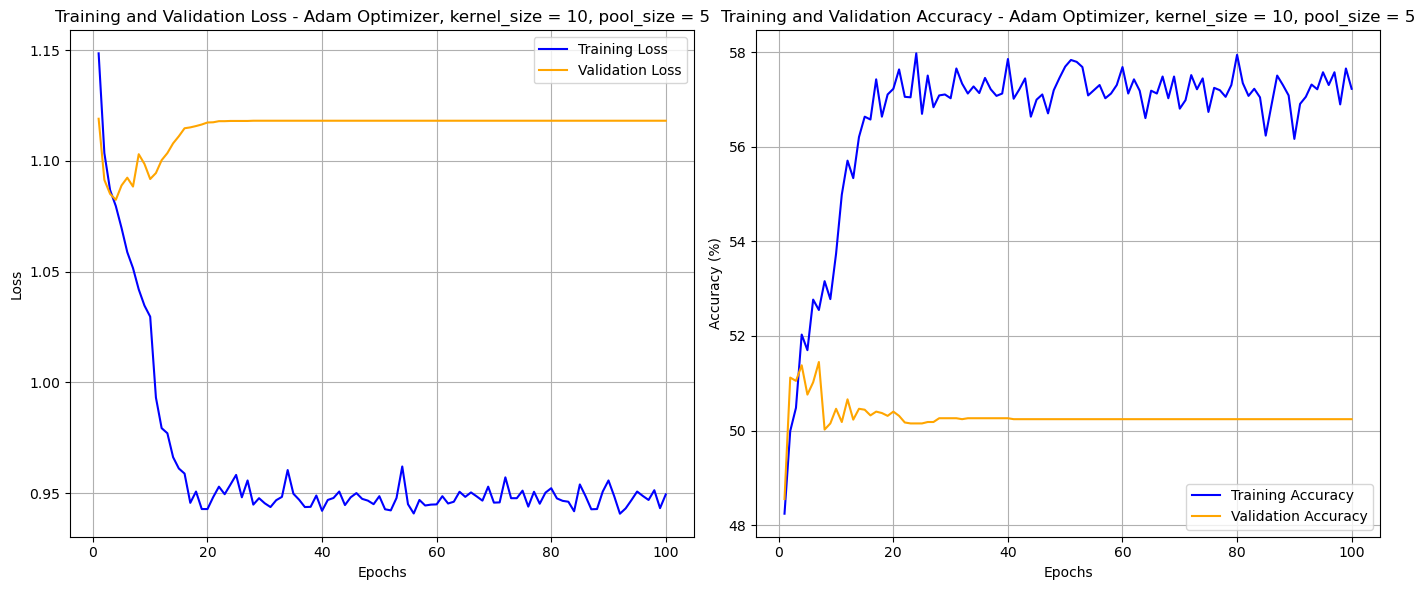

In [45]:
plot_metrics(train_losses, val_losses, train_accuracies, val_accuracies)

## Drawing the confusion matrix

In [46]:
# Get the class labels
class_labels = np.unique(test_true_labels)
print(class_labels)

[0. 1. 2. 3.]


In [47]:
# Create the confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions, labels=class_labels)

In [48]:
# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

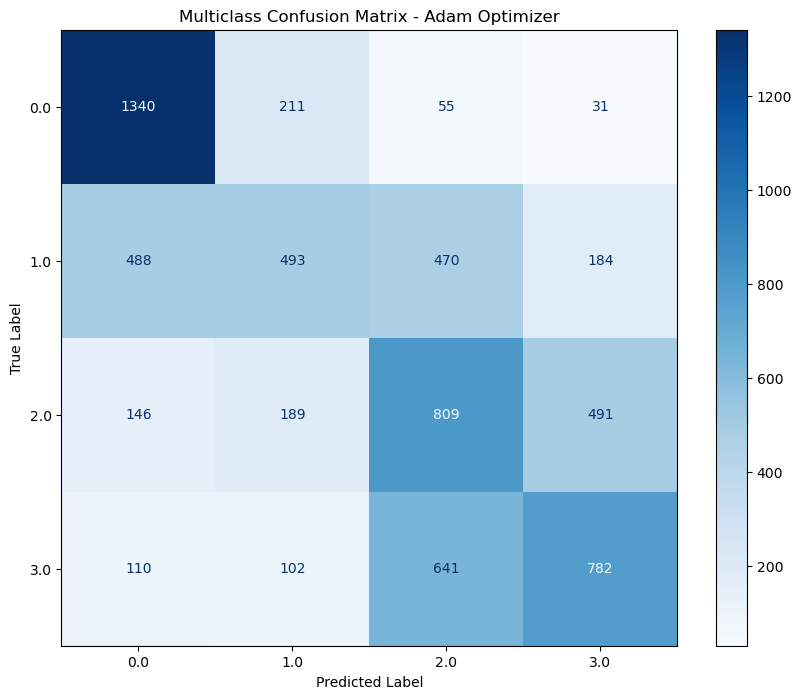

In [49]:
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')

# Customize the plot
plt.title(f'Multiclass Confusion Matrix - {optimizer_name} Optimizer')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

img_name = f"{item_name}-{optimizer_name}.png"
plt.savefig(os.path.join(OUTPUT_PATH, 'img', 'confusion_matrix', img_name))

# Show the plot
plt.show()

## Drawing ROC Curve

In [50]:
# Binarize the labels
n_classes = len(np.unique(test_true_labels))
y_true_bin = label_binarize(test_true_labels, classes=range(n_classes))

In [51]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], test_predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

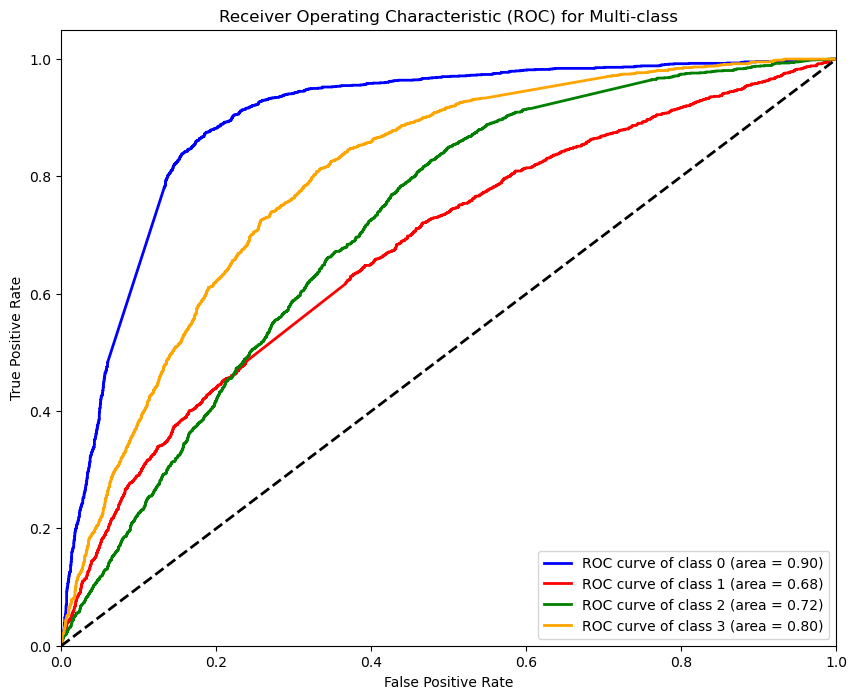

In [52]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Multi-class')
plt.legend(loc="lower right")

img_name = f"{item_name}-{optimizer_name}.png"
plt.savefig(os.path.join(OUTPUT_PATH, 'img', 'roc', img_name))

plt.show()

In [53]:
# Print AUC scores
for i in range(n_classes):
    print(f"AUC for class {i}: {roc_auc[i]:.2f}")

AUC for class 0: 0.90
AUC for class 1: 0.68
AUC for class 2: 0.72
AUC for class 3: 0.80


In [54]:
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), test_predicted_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
print(f"Micro-average AUC: {roc_auc['micro']:.2f}")

Micro-average AUC: 0.79


# Saving the experiment results

## Detailed experiment

In [55]:
# Create dataframe from array
experiment_results = {
    'train_loss': train_losses,
    'train_accuracy': train_accuracies,
    'train_auc': train_aucs,
    'val_loss': val_losses,
    'val_accuracy': val_accuracies,
    'val_auc': val_aucs
}

In [56]:
experiment_pl = pl.DataFrame(experiment_results)

In [57]:
experiment_pl.write_csv(os.path.join(OUTPUT_PATH, 'experiments', 'details', f'{item_name}-{optimizer_name}.csv'))

## Min-Avg-Max

In [58]:
def min_avg_max(lst):
    return round(min(lst), 2), round(sum(lst)/len(lst), 2), round(max(lst), 2)

In [59]:
train_loss_min, train_loss_avg, train_loss_max = min_avg_max(train_losses)
train_acc_min, train_acc_avg, train_acc_max = min_avg_max(train_accuracies)
train_auc_min, train_auc_avg, train_auc_max = min_avg_max(train_aucs)

print(f"{train_loss_min:.2f}, {train_loss_avg:.2f}, {train_loss_max:.2f}")
print(f"{train_acc_min}, {train_acc_avg}, {train_acc_max}")
print(f"{train_auc_min}, {train_auc_avg}, {train_auc_max}")

0.94, 0.96, 1.15
48.24, 56.59, 57.98
0.74, 0.81, 0.82


In [60]:
val_loss_min, val_loss_avg, val_loss_max = min_avg_max(val_losses)
val_acc_min, val_acc_avg, val_acc_max = min_avg_max(val_accuracies)
val_auc_min, val_auc_avg, val_auc_max = min_avg_max(val_aucs)

print(f"{val_loss_min:.2f}, {val_loss_avg:.2f}, {val_loss_max:.2f}")
print(f"{val_acc_min}, {val_acc_avg}, {val_acc_max}")
print(f"{val_auc_min}, {val_auc_avg}, {val_auc_max}")

1.08, 1.11, 1.12
48.55, 50.29, 51.45
0.75, 0.76, 0.77


In [61]:
print(f"{test_acc_score}, {test_auc_score}")

52.34, 0.77


In [62]:
# Prepare the output file
output_rows = []

output_rows.append([
    item_name,
    train_loss_min, train_loss_avg, train_loss_max,
    train_acc_min, train_acc_avg, train_acc_max,
    train_auc_min, train_auc_avg, train_auc_max,
    val_loss_min, val_loss_avg, val_loss_max,
    val_acc_min, val_acc_avg, val_acc_max,
    val_auc_min, val_auc_avg, val_auc_max,
    test_acc_score, test_auc_score
])

output_rows_df = pd.DataFrame(output_rows, 
    columns=[
        "item_name",
        "train_loss_min", "train_loss_avg", "train_loss_max",
        "train_acc_min", "train_acc_avg", "train_acc_max",
        "train_auc_min", "train_auc_avg", "train_auc_max",
        "val_loss_min", "val_loss_avg", "val_loss_max",
        "val_acc_min", "val_acc_avg", "val_acc_max",
        "val_auc_min", "val_auc_avg", "val_auc_max",
        "test_acc_score", "test_auc_score"
    ]
)

output_rows_df

,item_name,train_loss_min,train_loss_avg,train_loss_max,train_acc_min,train_acc_avg,train_acc_max,train_auc_min,train_auc_avg,train_auc_max,...,val_loss_avg,val_loss_max,val_acc_min,val_acc_avg,val_acc_max,val_auc_min,val_auc_avg,val_auc_max,test_acc_score,test_auc_score
0,H3K4me3-H3K9me3-H3K27me3,0.94,0.96,1.15,48.24,56.59,57.98,0.74,0.81,0.82,...,1.11,1.12,48.55,50.29,51.45,0.75,0.76,0.77,52.34,0.77


In [63]:
output_rows_df.to_csv(os.path.join(OUTPUT_PATH, "experiments", "min-avg-max", 
                              f"{item_name}-{optimizer_name}.csv"), 
                 header=True, index=False)